# 🔧 Notebook 01: SOC Tooling — FunctionTools, MCP & Evidence Packs

This notebook shows how to wire SOC enrichment tools into an Azure AI Agent, run an alert investigation, and capture evidence in a reusable pack. It uses FunctionTool for mock Sentinel enrichment and an optional MCP pattern for Sentinel server connectivity.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath("../src"))
import nest_asyncio; nest_asyncio.apply()
from soc_workshop.settings import get_settings
from soc_workshop.clients import get_project_client, configure_tracing
from soc_workshop.incident_schema import Alert, EvidenceItem, InvestigationRecord
from soc_workshop.tools.sentinel_mock import get_alert_details, get_related_alerts, get_sign_in_logs, get_entity_risk
from azure.ai.projects.models import PromptAgentDefinition, FunctionTool, MCPTool
from openai.types.responses.response_input_param import FunctionCallOutput

In [2]:
import inspect
from dataclasses import asdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

settings = get_settings()
configure_tracing()
project_client = get_project_client(settings)

ALERT_ID = "ALERT-2025-001"
PRIMARY_USER = "jdoe@contoso.com"
PRIMARY_IP = "185.220.101.45"
print(f"Model deployment: {settings.model_deployment}")

Model deployment: gpt-4.1


## FunctionTools: Your Agent's Investigative Toolkit

FunctionTools expose SOC enrichment functions directly to the agent so it can plan and call them autonomously. Here we register alert, related-alert, sign-in, and entity-risk pivots for rapid triage.

In [3]:
tool_functions = [get_alert_details, get_related_alerts, get_sign_in_logs, get_entity_risk]

def parse_parameters(fn):
    sig = inspect.signature(fn)
    return ", ".join([f"{name}: {param.annotation if param.annotation is not inspect._empty else 'Any'}" for name, param in sig.parameters.items()])

def first_doc_line(fn):
    doc = (inspect.getdoc(fn) or "").strip().splitlines()
    return doc[0] if doc else "No description"

tools_df = pd.DataFrame([
    {
        "tool_name": fn.__name__,
        "description": first_doc_line(fn),
        "parameters": parse_parameters(fn),
    }
    for fn in tool_functions
])
tools_df

,tool_name,description,parameters
0,get_alert_details,Return full details for a Sentinel alert by ID.,alert_id: str
1,get_related_alerts,"Find alerts that share an entity (IP, user, ho...",entity_value: str
2,get_sign_in_logs,Retrieve recent sign-in activity for a user pr...,user_principal: str
3,get_entity_risk,Look up the risk score for an entity.,"entity_type: str, entity_value: str"


In [4]:
tools = [
    FunctionTool(
        name="get_alert_details",
        description="Return full details for a Sentinel alert by ID.",
        parameters={
            "type": "object",
            "properties": {
                "alert_id": {"type": "string", "description": "The alert ID to look up"}
            },
            "required": ["alert_id"],
            "additionalProperties": False,
        },
        strict=True,
    ),
    FunctionTool(
        name="get_related_alerts",
        description="Find alerts that share an entity (IP, user, host, hash) with the given value.",
        parameters={
            "type": "object",
            "properties": {
                "entity_value": {"type": "string", "description": "Entity value to search for"}
            },
            "required": ["entity_value"],
            "additionalProperties": False,
        },
        strict=True,
    ),
    FunctionTool(
        name="get_sign_in_logs",
        description="Retrieve recent sign-in activity for a user principal name.",
        parameters={
            "type": "object",
            "properties": {
                "user_principal": {"type": "string", "description": "User principal name (e.g. jdoe@contoso.com)"}
            },
            "required": ["user_principal"],
            "additionalProperties": False,
        },
        strict=True,
    ),
    FunctionTool(
        name="get_entity_risk",
        description="Look up the risk score for an entity.",
        parameters={
            "type": "object",
            "properties": {
                "entity_type": {"type": "string", "description": "Entity type: user, ip, host, hash"},
                "entity_value": {"type": "string", "description": "Entity value to look up"}
            },
            "required": ["entity_type", "entity_value"],
            "additionalProperties": False,
        },
        strict=True,
    ),
]

agent = project_client.agents.create_version(
    agent_name="soc-enrichment-analyst",
    definition=PromptAgentDefinition(
        model=settings.model_deployment,
        instructions=(
            "You are a Tier-2 SOC enrichment analyst. Investigate the provided Sentinel alert by calling available tools. "
            "Correlate sign-in anomalies with endpoint telemetry and suspicious execution context. "
            "Check entity risk scores for users, IPs, and hosts to prioritize likely compromise paths. "
            "Pivot on related alerts to establish potential attack chain progression and ransomware staging behavior. "
            "Return a concise enrichment summary with key findings, high-confidence evidence, and recommended containment actions."
        ),
        tools=tools,
    ),
)
print(f"Created agent: {agent.name} v{agent.version}")

Created agent: soc-enrichment-analyst v1


In [5]:
# Map of tool name -> Python callable
TOOL_DISPATCH = {
    "get_alert_details": get_alert_details,
    "get_related_alerts": get_related_alerts,
    "get_sign_in_logs": get_sign_in_logs,
    "get_entity_risk": get_entity_risk,
}

def run_agent_with_tools(openai_client, agent, user_input, tool_dispatch, max_rounds=10):
    """Run agent with manual function-call loop until final text response."""
    response = openai_client.responses.create(
        input=user_input,
        model=settings.model_deployment,
        extra_body={"agent_reference": {"name": agent.name, "type": "agent_reference"}},
    )

    tool_call_log = []
    for _ in range(max_rounds):
        fn_calls = [item for item in response.output if item.type == "function_call"]
        if not fn_calls:
            break

        fn_outputs = []
        for call in fn_calls:
            fn = tool_dispatch.get(call.name)
            if fn is None:
                result = json.dumps({"error": f"Unknown function: {call.name}"})
            else:
                args = json.loads(call.arguments)
                result = fn(**args)

            tool_call_log.append({"tool": call.name, "args": call.arguments, "result_len": len(result)})
            fn_outputs.append(
                FunctionCallOutput(
                    type="function_call_output",
                    call_id=call.call_id,
                    output=result,
                )
            )

        response = openai_client.responses.create(
            input=fn_outputs,
            previous_response_id=response.id,
            extra_body={"agent_reference": {"name": agent.name, "type": "agent_reference"}},
        )

    return response, tool_call_log

openai_client = project_client.get_openai_client()

response, tool_call_log = run_agent_with_tools(
    openai_client,
    agent,
    f"Investigate alert {ALERT_ID}. Use available tools to enrich details, correlate related alerts, evaluate identity and IP risk, and produce a SOC evidence-focused summary.",
    TOOL_DISPATCH,
)

enrichment_result = response.output_text
print(enrichment_result or "No assistant response text returned.")

**SOC Enrichment Summary: ALERT-2025-001**

**Key Findings:**

- **Alert Context:** "Suspicious PowerShell execution with encoded command" detected on host WKS-FIN-PC04. Decoded PowerShell payload attempts external connection to IP 198.51.100.23, identified as a known Cobalt Strike C2. The execution originated from explorer.exe, indicating user-level initiation—often seen in ransomware staging.
- **Endpoint Evidence:** Host WKS-FIN-PC04 is tagged as "patient-zero" and "active-compromise" with a critical risk score (95). PowerShell abuse aligns with MITRE T1059.001 (Command Line Interface) and T1071.001 (Data Transfer via Application Layer Protocol), tactics used for execution and command-and-control.
- **User & Identity Anomalies:** User `jdoe@contoso.com` has a high risk score (70), flagged as "compromised-likely." Recent sign-in logs show:
  - Multiple successful logins on the endpoint (Seattle, WA).
  - Prior high-risk sign-ins from TOR (185.220.101.42, unknown device, no MFA) and a

In [6]:
tool_calls_df = pd.DataFrame(tool_call_log)
if not tool_calls_df.empty:
    tool_calls_df["tool_name"] = tool_calls_df["tool"]
if tool_calls_df.empty:
    tool_calls_df = pd.DataFrame([{"tool": "(no tool calls)", "args": "", "result_len": 0, "tool_name": "(no tool calls)"}])
tool_calls_df

,tool,args,result_len,tool_name
0,get_alert_details,"{""alert_id"":""ALERT-2025-001""}",1626,get_alert_details
1,get_related_alerts,"{""entity_value"":""ALERT-2025-001""}",2,get_related_alerts
2,get_sign_in_logs,"{""user_principal"":""jdoe@contoso.com""}",1328,get_sign_in_logs
3,get_entity_risk,"{""entity_type"":""user"",""entity_value"":""jdoe@con...",236,get_entity_risk
4,get_entity_risk,"{""entity_type"":""ip"",""entity_value"":""198.51.100...",232,get_entity_risk
5,get_entity_risk,"{""entity_type"":""host"",""entity_value"":""WKS-FIN-...",239,get_entity_risk


## MCP Integration: Connecting to Sentinel

MCP lets the same agent connect to external tool servers through a standard protocol, so SOC workflows can mix local function tools and remote capabilities. The block below adds Sentinel MCP only when configured in environment settings.

In [7]:
mcp_tool = None
if settings.mcp_server_url:
    try:
        mcp_tool = MCPTool(
            server_label=settings.mcp_server_label,
            server_url=settings.mcp_server_url,
            require_approval="never",  # auto-approve for workshop demo
        )
        print(f"MCP configured: {settings.mcp_server_label} -> {settings.mcp_server_url}")
    except Exception as exc:
        print(f"MCP configuration failed: {exc}")
else:
    print("MCP_SERVER_URL not set; skipping MCP tool registration.")

MCP_SERVER_URL not set; skipping MCP tool registration.


## Building the Evidence Pack

Now we normalize tool outputs into structured evidence entries suitable for handoff and downstream analysis. Evidence is categorized for quick SOC review across network, identity, endpoint, and threat-intel dimensions.

In [8]:
alert_details = json.loads(get_alert_details(ALERT_ID))
related_alerts = json.loads(get_related_alerts("10.0.14.88"))
sign_in_logs = json.loads(get_sign_in_logs(PRIMARY_USER))
user_risk = json.loads(get_entity_risk("user", PRIMARY_USER))
ip_risk = json.loads(get_entity_risk("ip", PRIMARY_IP))

evidence_items = [
    EvidenceItem(
        source="get_alert_details",
        category="endpoint",
        summary=f"Primary alert {alert_details.get('alert_id', ALERT_ID)}: {alert_details.get('title', 'Unknown')}",
        raw=alert_details,
    ),
    EvidenceItem(
        source="get_related_alerts",
        category="threat_intel",
        summary=f"Found {len(related_alerts)} related alerts indicating possible attack-chain progression",
        raw={"related_alerts": related_alerts},
    ),
    EvidenceItem(
        source="get_sign_in_logs",
        category="identity",
        summary=f"Collected {len(sign_in_logs)} sign-in events for {PRIMARY_USER}, including anomalous geolocation/risk context",
        raw={"sign_in_logs": sign_in_logs},
    ),
    EvidenceItem(
        source="get_entity_risk",
        category="identity",
        summary=f"User risk score for {PRIMARY_USER}: {user_risk.get('risk_score', 'n/a')} ({user_risk.get('risk_level', 'Unknown')})",
        raw=user_risk,
    ),
    EvidenceItem(
        source="get_entity_risk",
        category="network",
        summary=f"IP risk score for {PRIMARY_IP}: {ip_risk.get('risk_score', 'n/a')} ({ip_risk.get('risk_level', 'Unknown')})",
        raw=ip_risk,
    ),
]

if enrichment_result:
    evidence_items.append(EvidenceItem(
        source="agent_enrichment_summary",
        category="threat_intel",
        summary=enrichment_result[:300],
        raw={"full_summary": enrichment_result},
    ))

if not tool_calls_df.empty and "tool_name" in tool_calls_df.columns:
    category_map = {
        "get_alert_details": "endpoint",
        "get_related_alerts": "threat_intel",
        "get_sign_in_logs": "identity",
        "get_entity_risk": "network",
    }
    for _, row in tool_calls_df.iterrows():
        name = row.get("tool_name", "unknown")
        if name in category_map:
            evidence_items.append(EvidenceItem(
                source="tool_call_trace",
                category=category_map[name],
                summary=f"Tool call observed in run timeline: {name} (step {row.get('step_index')})",
                raw={
                    "step_index": row.get("step_index"),
                    "created_at": row.get("created_at"),
                    "status": row.get("status"),
                },
            ))

evidence_df = pd.DataFrame([
    {
        "source": e.source,
        "category": e.category,
        "summary": e.summary,
        "timestamp": e.timestamp,
    }
    for e in evidence_items
])
evidence_df

,source,category,summary,timestamp
0,get_alert_details,endpoint,Primary alert ALERT-2025-001: Suspicious Power...,2026-03-08T21:47:58.466761
1,get_related_alerts,threat_intel,Found 0 related alerts indicating possible att...,2026-03-08T21:47:58.466797
2,get_sign_in_logs,identity,Collected 4 sign-in events for jdoe@contoso.co...,2026-03-08T21:47:58.466804
3,get_entity_risk,identity,User risk score for jdoe@contoso.com: 70 (High),2026-03-08T21:47:58.466811
4,get_entity_risk,network,IP risk score for 185.220.101.45: 25 (Low),2026-03-08T21:47:58.466817
5,agent_enrichment_summary,threat_intel,**SOC Enrichment Summary: ALERT-2025-001**\n\n...,2026-03-08T21:47:58.467098
6,tool_call_trace,endpoint,Tool call observed in run timeline: get_alert_...,2026-03-08T21:47:58.468439
7,tool_call_trace,threat_intel,Tool call observed in run timeline: get_relate...,2026-03-08T21:47:58.468606
8,tool_call_trace,identity,Tool call observed in run timeline: get_sign_i...,2026-03-08T21:47:58.468676
9,tool_call_trace,network,Tool call observed in run timeline: get_entity...,2026-03-08T21:47:58.468753


## Evidence Collection & Visualization

With all enrichment data retrieved, we now assemble a structured evidence pack categorized by network, identity, endpoint, and threat intelligence. Each piece of evidence includes source, category, summary, and timestamp for audit trails. We also visualize evidence distribution to highlight investigation focus areas.

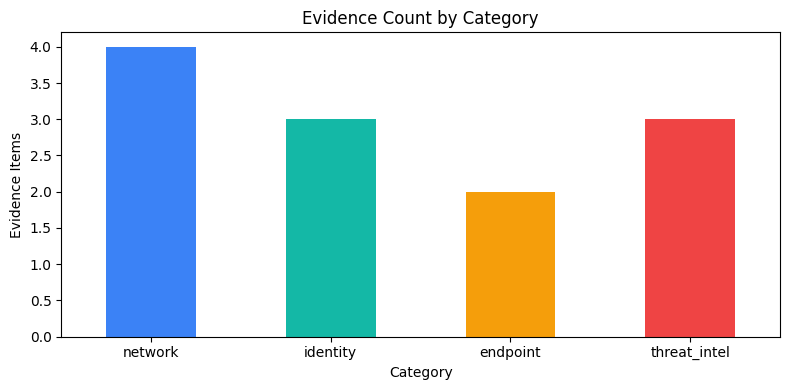

In [9]:
category_order = ["network", "identity", "endpoint", "threat_intel"]
counts = evidence_df["category"].value_counts().reindex(category_order, fill_value=0)

plt.figure(figsize=(8, 4))
counts.plot(kind="bar", color=["#3b82f6", "#14b8a6", "#f59e0b", "#ef4444"])
plt.title("Evidence Count by Category")
plt.xlabel("Category")
plt.ylabel("Evidence Items")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
alert_obj = Alert(
    alert_id=alert_details.get("alert_id", ALERT_ID),
    title=alert_details.get("title", "Cobalt Strike PowerShell stager on WKS-FIN-PC04"),
    severity=alert_details.get("severity", "High"),
    description=alert_details.get("description", "SOC alert enrichment for suspicious endpoint execution and identity anomalies."),
    timestamp=alert_details.get("timestamp", pd.Timestamp.utcnow().isoformat()),
    source=alert_details.get("source", "Microsoft Sentinel"),
    tactics=alert_details.get("tactics", []),
    techniques=alert_details.get("techniques", []),
    raw_json=alert_details,
)

record = InvestigationRecord(
    incident_id="INC-2025-001",
    title="ALERT-2025-001 SOC Enrichment",
    alerts=[alert_obj],
    evidence=evidence_items,
    hypothesis=(
        "Adversary activity likely progressed from anomalous identity access to endpoint staging, "
        "with related detections suggesting ransomware attack-chain development."
    ),
    verdict="True Positive",
    confidence=0.86,
    recommended_actions=[
        "Isolate impacted endpoint WKS-FIN-PC04 and acquire volatile artifacts",
        "Disable/reset credentials for jdoe@contoso.com and revoke active sessions",
        "Block high-risk source IPs and TOR egress paths at perimeter controls",
        "Hunt for Cobalt Strike and ransomware precursor artifacts across hosts",
    ],
    thread_id=response.id,
    agent_ids=[f"{agent.name}:{agent.version}"],
)

out_path = Path("../data/investigation_01.json")
out_path.parent.mkdir(parents=True, exist_ok=True)
out_path.write_text(record.to_json(indent=2), encoding="utf-8")
print(f"Saved investigation record: {out_path.resolve()}")

Saved investigation record: C:\repo\agentic-soc-army\data\investigation_01.json


### (optional) Cleanup

In [ ]:
# (Optional) uncomment to clean up agents
# project_client.agents.delete_version(agent_name=agent.name, agent_version=agent.version)
# openai_client.close()
# print(f"Deleted agent: {agent.name} v{agent.version}")

Deleted agent: soc-enrichment-analyst v1


## What's Next

Continue to **Notebook 02** to add retrieval-augmented enrichment and deeper SOC reasoning with indexed security content.

## Summary of this notebook
- Register SOC enrichment FunctionTools and run a tool-calling agent against a primary alert.
- Optionally configure an MCP tool for Sentinel connectivity.
- Normalize tool outputs into an evidence pack, visualize counts, and save investigation_01.json.